# 🔬 Comparativa de Modelos NER

Benchmark **separado por idioma** sobre corpus estándar:
- 🇪🇸 **CoNLL-2002 ES** (test set, noticias EFE) — para modelos en español
- 🇬🇧 **CoNLL-2003 EN** (test set, Reuters) — para modelos en inglés

Cada modelo se evalúa **únicamente sobre el corpus de su idioma**, garantizando comparaciones justas.

---

## ¿Qué miden las métricas?

| Métrica | Condición de acierto | Interpretación |
|---|---|---|
| **Exact F1** | Inicio + fin + tipo coinciden **exactamente** con gold | Criterio estricto oficial (CoNLL-2003) |
| **Partial F1** | El span se **solapa ≥ 50%** (Jaccard) con gold y mismo tipo | Tolera desalineación de tokenización |

El **gap Partial − Exact** mide errores de bordes de span, no de comprensión semántica.

**Ejemplo**: Gold = `"Banco Santander"` (pos 3–18)  
→ Predicción = `"El Banco Santander"` (pos 0–18)  
→ Exact: ❌ FP (offsets distintos) | Partial: ✅ TP (Jaccard = 15/19 ≈ 0.79 ≥ 0.5)

---

## Modelos evaluados

| Modelo | Framework | Corpus de evaluación |
|---|---|---|
| `es_core_news_sm` | spaCy | CoNLL-2002 ES |
| `es_core_news_md` | spaCy | CoNLL-2002 ES |
| `es_core_news_lg` | spaCy | CoNLL-2002 ES |
| `en_core_web_sm`  | spaCy | CoNLL-2003 EN |
| `en_core_web_trf` | spaCy | CoNLL-2003 EN |
| `bert-base-NER`   | HuggingFace | CoNLL-2003 EN |
| `stanza-es`       | Stanza | CoNLL-2002 ES |
| `stanza-en`       | Stanza | CoNLL-2003 EN |
| `flair-ner-fast`  | Flair | CoNLL-2003 EN |
| `flair-ner-large` | Flair | CoNLL-2003 EN |
| `gliner_small-v2.1` | GLiNER | CoNLL-2002 ES |
| `gliner_medium-v2.1` | GLiNER | CoNLL-2002 ES |

---

## Estructura del cuaderno

| Sección | Contenido |
|---|---|
| 0 | Instalación |
| 1 | Imports y configuración |
| 2 | Corpus (CoNLL-2002 ES + CoNLL-2003 EN) |
| 3 | Funciones de evaluación (exact + partial + timing CPU/GPU) |
| 4 | Evaluación de todos los modelos |
| 5 | **Tabla comparativa** con ranking por idioma |
| 6 | Heatmap F1 por categoría (PER/ORG/LOC/MISC) |
| 7 | Pipeline de filtrado multicapa |
| 8 | Comparativa antes/después de filtrado |
| 9 | Visualizaciones |
| 10 | Exportación CSV + LaTeX |


## 0. Instalación

In [ ]:
!pip install -q spacy stanza flair transformers torch gliner pandas tabulate seaborn matplotlib requests
!python -m spacy download es_core_news_sm -q
!python -m spacy download es_core_news_md -q
!python -m spacy download es_core_news_lg -q
!python -m spacy download en_core_web_sm  -q
!python -m spacy download en_core_web_trf -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 56.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 127.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.4/170.4 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 1. Imports y configuración

In [ ]:
import warnings, time, re, urllib.request
from collections import defaultdict
warnings.filterwarnings('ignore')

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

HAS_GPU = torch.cuda.is_available()
print(f'GPU disponible: {HAS_GPU}')
if HAS_GPU:
    print(f'  → {torch.cuda.get_device_name(0)}')
else:
    print('  → Solo se medirá tiempo CPU. En Colab: Entorno de ejecución > Cambiar tipo → GPU T4')

COLORS = {
    'spaCy':'#09A3D5', 'HuggingFace':'#FF9D00',
    'Stanza':'#6DB33F', 'Flair':'#C84B2F', 'GLiNER':'#7B3BC8',
}

LABEL_MAP = {
    'PER':'PER','PERSON':'PER','B-PER':'PER','I-PER':'PER','S-PER':'PER','E-PER':'PER',
    'ORG':'ORG','NORP':'ORG','B-ORG':'ORG','I-ORG':'ORG','S-ORG':'ORG','E-ORG':'ORG',
    'LOC':'LOC','GPE':'LOC','FAC':'LOC','B-LOC':'LOC','I-LOC':'LOC','S-LOC':'LOC','E-LOC':'LOC',
    'MISC':'MISC','PRODUCT':'MISC','EVENT':'MISC','WORK_OF_ART':'MISC',
    'B-MISC':'MISC','I-MISC':'MISC','S-MISC':'MISC','E-MISC':'MISC',
}
def normalize_label(lbl):
    return LABEL_MAP.get(lbl.upper().strip(), 'MISC')

ALL_RESULTS = []
print('✅ Imports OK')


GPU disponible: True
  → Tesla T4
✅ Imports OK


## 2. Corpus

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CORPUS DE EVALUACIÓN
# ══════════════════════════════════════════════════════════════════
# • CoNLL-2002 ES — descarga directa desde GitHub (corpus público)
# • CoNLL-2003 EN — descarga vía HuggingFace Parquet (sin loading script)
#   Si Parquet falla: colocar 'eng.testb' en el mismo directorio que el
#   notebook (fichero del CoNLL-2003 original, descargable en
#   https://data.deepai.org/conll2003.zip)
# ══════════════════════════════════════════════════════════════════

import os, io, urllib.request

# ── Parser IOB genérico ───────────────────────────────────────
def _iob_to_spans(words, labels):
    text = ' '.join(words)
    entities, char_starts, cur = [], [], 0
    for w in words:
        char_starts.append(cur); cur += len(w) + 1
    i = 0
    while i < len(labels):
        lbl = labels[i]
        if lbl.startswith('B-') or lbl.startswith('S-'):
            etype = lbl[2:]; start = char_starts[i]; j = i + 1
            while j < len(labels) and (labels[j].startswith('I-') or labels[j].startswith('E-')):
                j += 1
            end = char_starts[j-1] + len(words[j-1])
            entities.append((start, end, etype, text[start:end]))
            i = j
        else:
            i += 1
    return {'text': text, 'entities': entities}

def load_conll_iob(filepath):
    """Parsea cualquier fichero en formato CoNLL columnar (word ... ner_tag)."""
    sentences, words, labels = [], [], []
    with open(filepath, encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('-DOCSTART-'):
                if words:
                    sentences.append(_iob_to_spans(words, labels))
                    words, labels = [], []
            else:
                parts = line.split()
                words.append(parts[0]); labels.append(parts[-1])
    if words:
        sentences.append(_iob_to_spans(words, labels))
    return sentences


# ── CoNLL-2002 ES ─────────────────────────────────────────────
CONLL02_URL  = 'https://raw.githubusercontent.com/teropa/nlp/master/resources/corpora/conll2002/esp.testb'
CONLL02_FILE = 'conll2002_es_test.txt'
N_ES = 200   # frases a usar; None = todas (1517)

try:
    urllib.request.urlretrieve(CONLL02_URL, CONLL02_FILE)
    _all_es = load_conll_iob(CONLL02_FILE)
    CORPUS_ES = _all_es[:N_ES] if N_ES else _all_es
    print(f'✅ CoNLL-2002 ES: {len(_all_es)} frases totales — usando {len(CORPUS_ES)}')
except Exception as e:
    print(f'⚠️  CoNLL-2002 no disponible ({e})')
    CORPUS_ES = None


# ── CoNLL-2003 EN ─────────────────────────────────────────────
# Etiquetas del dataset HuggingFace (índices enteros → strings IOB2)
_CONLL03_LABELS = ['O','B-PER','I-PER','B-ORG','I-ORG','B-LOC','I-LOC','B-MISC','I-MISC']
N_EN = 200   # frases a usar; None = todas (3684)

CORPUS_EN = None

# Opción 1 — HuggingFace Parquet (sin loading script)
if CORPUS_EN is None:
    try:
        from datasets import load_dataset
        _PARQUET = (
            'https://huggingface.co/datasets/conll2003/resolve/'
            'refs%2Fconvert%2Fparquet/conll2003/test/0000.parquet'
        )
        ds = load_dataset('parquet', data_files={'test': _PARQUET}, split='test')
        _rows = []
        for ex in ds:
            toks = list(ex['tokens'])
            tags = ex['ner_tags']
            iob  = [_CONLL03_LABELS[t] if isinstance(t, int) else t for t in tags]
            _rows.append(_iob_to_spans(toks, iob))
        CORPUS_EN = _rows[:N_EN] if N_EN else _rows
        print(f'✅ CoNLL-2003 EN (Parquet HF): {len(_rows)} frases — usando {len(CORPUS_EN)}')
    except Exception as e:
        print(f'   Opción 1 (Parquet HF) falló: {e}')

# Opción 2 — fichero eng.testb local
if CORPUS_EN is None:
    for _fname in ['eng.testb', 'conll2003_en_test.txt']:
        if os.path.exists(_fname):
            _all_en = load_conll_iob(_fname)
            CORPUS_EN = _all_en[:N_EN] if N_EN else _all_en
            print(f'✅ CoNLL-2003 EN (fichero local {_fname}): {len(_all_en)} frases — usando {len(CORPUS_EN)}')
            break
    if CORPUS_EN is None:
        print('   Opción 2 (fichero local) no encontrada.')
        print('   → Descarga https://data.deepai.org/conll2003.zip y coloca eng.testb aquí.')

# Opción 3 — muestra sintética representativa (smoke-test)
if CORPUS_EN is None:
    print('⚠️  Usando muestra sintética EN (smoke-test — métricas no comparables con literatura)')
    CORPUS_EN = [
        {'text':'EU rejects German call to boycott British lamb .',
         'entities':[(0,2,'ORG','EU'),(10,16,'MISC','German'),(36,43,'MISC','British')]},
        {'text':'Peter Blackburn',
         'entities':[(0,15,'PER','Peter Blackburn')]},
        {'text':'BRUSSELS 1996-08-22',
         'entities':[(0,8,'LOC','BRUSSELS')]},
        {'text':'The European Commission said on Thursday it disagreed with the German view .',
         'entities':[(4,23,'ORG','European Commission'),(62,68,'MISC','German')]},
        {'text':'Germany \'s representative to the European Union \'s veterinary committee Werner Zwingmann said on Wednesday .',
         'entities':[(0,7,'LOC','Germany'),(33,46,'ORG','European Union'),(68,83,'PER','Werner Zwingmann')]},
        {'text':'Barack Obama visited the United Nations headquarters in New York .',
         'entities':[(0,12,'PER','Barack Obama'),(25,39,'ORG','United Nations'),(55,63,'LOC','New York')]},
        {'text':'Elon Musk announced that Tesla will build a new Gigafactory in Berlin .',
         'entities':[(0,9,'PER','Elon Musk'),(24,29,'ORG','Tesla'),(62,68,'LOC','Berlin')]},
        {'text':'The European Central Bank raised interest rates .',
         'entities':[(4,26,'ORG','European Central Bank')]},
        {'text':'Cristiano Ronaldo joined Al Nassr FC after leaving Manchester United .',
         'entities':[(0,17,'PER','Cristiano Ronaldo'),(25,35,'ORG','Al Nassr FC'),(51,68,'ORG','Manchester United')]},
        {'text':'Google DeepMind published a paper on protein folding .',
         'entities':[(0,14,'ORG','Google DeepMind')]},
    ] * 20   # 200 frases

print()
if CORPUS_ES:
    n_ents_es = sum(len(s['entities']) for s in CORPUS_ES)
    print(f'📊 CORPUS_ES: {len(CORPUS_ES)} frases, {n_ents_es} entidades')
n_ents_en = sum(len(s['entities']) for s in CORPUS_EN)
print(f'📊 CORPUS_EN: {len(CORPUS_EN)} frases, {n_ents_en} entidades')


✅ CoNLL-2002 ES: 1517 frases totales — usando 200


0000.parquet:   0%|          | 0.00/283k [00:00<?, ?B/s]

Generating test split: 0 examples [00:00, ? examples/s]

✅ CoNLL-2003 EN (Parquet HF): 3453 frases — usando 200

📊 CORPUS_ES: 200 frases, 462 entidades
📊 CORPUS_EN: 200 frases, 407 entidades


## 3. Funciones de evaluación

- **`exact_metrics`**: acierto = inicio + fin + tipo coinciden exactamente
- **`partial_metrics`**: acierto = Jaccard(pred, gold) ≥ 0.5 con mismo tipo
- **`measure_time`**: mide latencia media por frase en CPU y (si disponible) GPU


In [ ]:
def exact_metrics(gold, pred):
    g = {(s,e,normalize_label(l)) for s,e,l,_ in gold}
    p = {(s,e,normalize_label(l)) for s,e,l,_ in pred}
    tp=len(g&p); fp=len(p-g); fn=len(g-p)
    P=tp/(tp+fp) if tp+fp else 0.; R=tp/(tp+fn) if tp+fn else 0.
    return {'tp':tp,'fp':fp,'fn':fn,'P':P,'R':R,'F1':2*P*R/(P+R) if P+R else 0.}

def partial_metrics(gold, pred, min_j=0.5):
    matched=set(); tp=fp=0
    for ps,pe,pl,_ in pred:
        pl_n=normalize_label(pl); bj,bi=0,None
        for i,(gs,ge,gl,_) in enumerate(gold):
            if normalize_label(gl)!=pl_n or i in matched: continue
            inter=max(0,min(pe,ge)-max(ps,gs)); union=max(pe,ge)-min(ps,gs)
            j=inter/union if union else 0
            if j>bj: bj,bi=j,i
        if bj>=min_j and bi is not None: tp+=1; matched.add(bi)
        else: fp+=1
    fn=len(gold)-len(matched)
    P=tp/(tp+fp) if tp+fp else 0.; R=tp/(tp+fn) if tp+fn else 0.
    return {'tp':tp,'fp':fp,'fn':fn,'P':P,'R':R,'F1':2*P*R/(P+R) if P+R else 0.}

def aggregate(results):
    tp=sum(r['tp'] for r in results); fp=sum(r['fp'] for r in results); fn=sum(r['fn'] for r in results)
    P=tp/(tp+fp) if tp+fp else 0.; R=tp/(tp+fn) if tp+fn else 0.
    return {'tp':tp,'fp':fp,'fn':fn,'P':P,'R':R,'F1':2*P*R/(P+R) if P+R else 0.}

def category_metrics(corpus, pred_fn, match_fn=partial_metrics):
    cat_r=defaultdict(list)
    for s in corpus:
        preds=pred_fn(s['text'])
        for cat in ['PER','ORG','LOC','MISC']:
            g=[(a,b,l,t) for a,b,l,t in s['entities'] if normalize_label(l)==cat]
            p=[(a,b,l,t) for a,b,l,t in preds       if normalize_label(l)==cat]
            cat_r[cat].append(match_fn(g,p))
    return {c:aggregate(v) for c,v in cat_r.items()}

def measure_time(pred_fn, corpus, device_label):
    """
    Mide latencia media (ms/frase) sobre el corpus.
    device_label: 'CPU' o 'GPU' — solo para logging.
    """
    times = []
    for s in corpus:
        t0 = time.perf_counter()
        pred_fn(s['text'])
        times.append((time.perf_counter()-t0)*1000)
    return round(float(np.mean(times)), 1)

def evaluate_model(name, library, lang, corpus, pred_fn, pred_fn_gpu=None):
    """
    Evalúa métricas y mide tiempos CPU (siempre) y GPU (si pred_fn_gpu se proporciona).
    pred_fn_gpu: versión del predictor sobre GPU; None si el modelo no soporta GPU.
    """
    exact_r, partial_r = [], []
    for s in corpus:
        preds = pred_fn(s['text'])
        exact_r.append(exact_metrics(s['entities'], preds))
        partial_r.append(partial_metrics(s['entities'], preds))
    ea = aggregate(exact_r)
    pa = aggregate(partial_r)

    cpu_ms = measure_time(pred_fn, corpus, 'CPU')
    gpu_ms = measure_time(pred_fn_gpu, corpus, 'GPU') if pred_fn_gpu and HAS_GPU else None

    row = {
        'Librería':library, 'Modelo':name, 'Idioma':lang,
        'Exact-P':ea['P'],  'Exact-R':ea['R'],  'Exact-F1':ea['F1'],
        'Partial-P':pa['P'],'Partial-R':pa['R'],'Partial-F1':pa['F1'],
        'FP-ex':ea['fp'], 'FN-ex':ea['fn'],
        'CPU_ms':cpu_ms, 'GPU_ms':gpu_ms,
    }
    ALL_RESULTS.append(row)
    gpu_str = f'  GPU={gpu_ms:.1f}ms' if gpu_ms is not None else '  GPU=N/A'
    print(f'  {name:35s}  ExactF1={ea["F1"]:.3f}  PartialF1={pa["F1"]:.3f}'
          f'  P={pa["P"]:.3f}  R={pa["R"]:.3f}  CPU={cpu_ms:.1f}ms{gpu_str}')
    return row

print('✅ Funciones de evaluación listas')


✅ Funciones de evaluación listas


## 4. Evaluación de modelos

Cada sección carga un framework y ejecuta todos sus modelos verificados.
La función `evaluate_model` mide automáticamente CPU y GPU (si hay CUDA disponible).


### 4a. spaCy

In [ ]:
import spacy

SPACY_CONFIGS = [
    ('es_core_news_sm', 'ES', CORPUS_ES),
    ('es_core_news_md', 'ES', CORPUS_ES),
    ('es_core_news_lg', 'ES', CORPUS_ES),
    ('en_core_web_sm',  'EN', CORPUS_EN),
    ('en_core_web_trf', 'EN', CORPUS_EN),
]

SPACY_PRED_FNS = {}
print('spaCy models')
for mname, lang, corpus in SPACY_CONFIGS:
    if corpus is None:
        print(f'  ⏭️  {mname} omitido — corpus {lang} no disponible'); continue
    try:
        # ── CPU: cargar siempre en CPU explícitamente ─────────
        spacy.require_cpu()
        nlp_cpu = spacy.load(mname)
        def make_pred(m):
            def pred(text):
                return [(e.start_char, e.end_char, e.label_, e.text) for e in m(text).ents]
            return pred
        pred_cpu = make_pred(nlp_cpu)

        # ── GPU: instancia separada, sin volver a require_cpu() ─
        # No llamamos require_cpu() tras prefer_gpu() para evitar
        # el error 'tensors on different devices'
        pred_gpu = None
        if HAS_GPU:
            try:
                spacy.prefer_gpu()
                nlp_gpu = spacy.load(mname)
                pred_gpu = make_pred(nlp_gpu)
                # Medir tiempo GPU aquí mismo, antes de cambiar contexto
                gpu_ms = measure_time(pred_gpu, corpus, 'GPU')
                # Volver a CPU para el resto de celdas usando una nueva carga
                spacy.require_cpu()
            except Exception as eg:
                print(f'    GPU timing omitido para {mname}: {eg}')
                gpu_ms = None
                spacy.require_cpu()
        else:
            gpu_ms = None

        SPACY_PRED_FNS[mname] = pred_cpu

        # Calcular métricas y tiempo CPU, luego registrar con gpu_ms ya medido
        import time as _time
        exact_r, partial_r, inf_times = [], [], []
        for s in corpus:
            t0 = _time.perf_counter()
            preds = pred_cpu(s['text'])
            inf_times.append((_time.perf_counter()-t0)*1000)
            exact_r.append(exact_metrics(s['entities'], preds))
            partial_r.append(partial_metrics(s['entities'], preds))
        ea  = aggregate(exact_r)
        pa  = aggregate(partial_r)
        cpu_ms = round(float(np.mean(inf_times)), 1)
        gpu_str = f'  GPU={gpu_ms:.1f}ms' if gpu_ms is not None else '  GPU=N/A'
        row = {
            'Librería':'spaCy', 'Modelo':mname, 'Idioma':lang,
            'Exact-P':ea['P'],  'Exact-R':ea['R'],  'Exact-F1':ea['F1'],
            'Partial-P':pa['P'],'Partial-R':pa['R'],'Partial-F1':pa['F1'],
            'FP-ex':ea['fp'], 'FN-ex':ea['fn'],
            'CPU_ms':cpu_ms, 'GPU_ms':gpu_ms,
        }
        ALL_RESULTS.append(row)
        print(f'  {mname:35s}  ExactF1={ea["F1"]:.3f}  PartialF1={pa["F1"]:.3f}'
              f'  P={pa["P"]:.3f}  R={pa["R"]:.3f}  CPU={cpu_ms:.1f}ms{gpu_str}')

    except OSError:
        print(f'  ⚠️  {mname} no instalado — ejecutar: python -m spacy download {mname}')
    except Exception as e:
        print(f'  ⚠️  {mname}: {e}')
        spacy.require_cpu()  # asegurar contexto CPU aunque falle


spaCy models
  es_core_news_sm                      ExactF1=0.572  PartialF1=0.610  P=0.602  R=0.619  CPU=15.1ms  GPU=84.7ms
  es_core_news_md                      ExactF1=0.689  PartialF1=0.732  P=0.720  R=0.745  CPU=8.4ms  GPU=22.1ms
  es_core_news_lg                      ExactF1=0.727  PartialF1=0.779  P=0.772  R=0.786  CPU=8.6ms  GPU=17.3ms
  en_core_web_sm                       ExactF1=0.477  PartialF1=0.514  P=0.436  R=0.624  CPU=8.5ms  GPU=15.0ms
  en_core_web_trf                      ExactF1=0.594  PartialF1=0.628  P=0.521  R=0.789  CPU=120.3ms  GPU=21.3ms


### 4b. HuggingFace

Solo `dslim/bert-base-NER` (BERT fine-tuned CoNLL-2003 EN).  
`PlanTL-GOB-ES/roberta-base-bne-capitel-ner` fue eliminado: modelo privado/borrado de HuggingFace Hub.


In [ ]:
from transformers import pipeline as hf_pipeline

# bert-base-NER: fine-tuned CoNLL-2003 EN → evaluado sobre CORPUS_EN
HF_PRED_FNS = {}
print('HuggingFace models')
try:
    pipe_cpu = hf_pipeline('ner', model='dslim/bert-base-NER',
                           device=-1, aggregation_strategy='simple')
    def hf_pred_cpu(text):
        return [(e['start'],e['end'],e['entity_group'],e['word']) for e in pipe_cpu(text)]

    hf_pred_gpu = None
    if HAS_GPU:
        pipe_gpu = hf_pipeline('ner', model='dslim/bert-base-NER',
                               device=0, aggregation_strategy='simple')
        def hf_pred_gpu(text):
            return [(e['start'],e['end'],e['entity_group'],e['word']) for e in pipe_gpu(text)]

    HF_PRED_FNS['bert-base-NER'] = hf_pred_cpu
    evaluate_model('bert-base-NER', 'HuggingFace', 'EN', CORPUS_EN, hf_pred_cpu, hf_pred_gpu)
except Exception as e:
    print(f'  ⚠️  bert-base-NER: {e}')


HuggingFace models


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  bert-base-NER                        ExactF1=0.530  PartialF1=0.755  P=0.635  R=0.931  CPU=149.9ms  GPU=12.3ms


### 4c. Stanza

In [ ]:
import stanza

STANZA_PRED_FNS = {}
STANZA_CONFIGS = [
    ('es', 'ES', CORPUS_ES),
    ('en', 'EN', CORPUS_EN),
]
print('Stanza models')
for code_lang, lang, corpus in STANZA_CONFIGS:
    if corpus is None:
        print(f'  ⏭️  stanza-{code_lang} omitido — corpus {lang} no disponible'); continue
    try:
        stanza.download(code_lang, verbose=False)
        nlp_st = stanza.Pipeline(code_lang, processors='tokenize,ner',
                                 verbose=False, use_gpu=HAS_GPU)
        def make_st(m):
            def pred(text):
                doc = m(text)
                return [(e.start_char,e.end_char,e.type,e.text)
                        for sent in doc.sentences for e in sent.ents]
            return pred
        pred_fn = make_st(nlp_st)
        name = f'stanza-{code_lang}'
        STANZA_PRED_FNS[name] = pred_fn
        evaluate_model(name, 'Stanza', lang, corpus, pred_fn,
                       pred_fn_gpu=pred_fn if HAS_GPU else None)
    except Exception as e:
        print(f'  ⚠️  stanza-{code_lang}: {e}')


Stanza models
  stanza-es                            ExactF1=0.879  PartialF1=0.919  P=0.922  R=0.916  CPU=64.1ms  GPU=63.4ms
  stanza-en                            ExactF1=0.579  PartialF1=0.622  P=0.512  R=0.791  CPU=30.0ms  GPU=29.7ms


### 4d. Flair

In [ ]:
from flair.data import Sentence as FlairSentence
from flair.models import SequenceTagger

# NOTA: Flair gestiona el dispositivo internamente mediante sus propios
# embeddings contextuales (FlairEmbeddings, TransformerWordEmbeddings).
# Llamar a .to('cuda') mueve el tagger pero NO los embeddings cargados
# perezosamente, produciendo el error 'tensors on different devices'.
# Solución: dejar que Flair elija el dispositivo automáticamente al cargar
# (usa CUDA si está disponible) y medir solo un tiempo de inferencia.
# El tiempo reflejará GPU si hay CUDA, CPU en caso contrario.

FLAIR_PRED_FNS = {}
FLAIR_CONFIGS = [
    ('flair/ner-english-fast',  'flair-ner-fast',  'EN', CORPUS_EN),
    ('flair/ner-english-large', 'flair-ner-large', 'EN', CORPUS_EN),
]
print('Flair models')
_flair_device = 'GPU' if HAS_GPU else 'CPU'

for tag, name, lang, corpus in FLAIR_CONFIGS:
    if corpus is None:
        print(f'  ⏭️  {name} omitido — corpus {lang} no disponible'); continue
    try:
        # Flair elige dispositivo automáticamente; no forzar .to()
        tagger = SequenceTagger.load(tag)

        def make_flair_pred(t):
            def pred(text):
                s = FlairSentence(text)
                t.predict(s)
                return [(sp.start_position, sp.end_position,
                         sp.get_label('ner').value, sp.text)
                        for sp in s.get_spans('ner')]
            return pred

        pred_fn = make_flair_pred(tagger)

        # Métricas
        import time as _t
        exact_r, partial_r, inf_times = [], [], []
        for s in corpus:
            t0 = _t.perf_counter()
            preds = pred_fn(s['text'])
            inf_times.append((_t.perf_counter() - t0) * 1000)
            exact_r.append(exact_metrics(s['entities'], preds))
            partial_r.append(partial_metrics(s['entities'], preds))

        ea  = aggregate(exact_r)
        pa  = aggregate(partial_r)
        inf_ms = round(float(np.mean(inf_times)), 1)

        # CPU_ms y GPU_ms según dispositivo real usado por Flair
        cpu_ms = inf_ms if not HAS_GPU else None
        gpu_ms = inf_ms if HAS_GPU     else None

        FLAIR_PRED_FNS[name] = pred_fn
        row = {
            'Librería':'Flair', 'Modelo':name, 'Idioma':lang,
            'Exact-P':ea['P'],  'Exact-R':ea['R'],  'Exact-F1':ea['F1'],
            'Partial-P':pa['P'],'Partial-R':pa['R'],'Partial-F1':pa['F1'],
            'FP-ex':ea['fp'], 'FN-ex':ea['fn'],
            'CPU_ms':cpu_ms, 'GPU_ms':gpu_ms,
        }
        ALL_RESULTS.append(row)
        print(f'  {name:35s}  ExactF1={ea["F1"]:.3f}  PartialF1={pa["F1"]:.3f}'
              f'  P={pa["P"]:.3f}  R={pa["R"]:.3f}  {_flair_device}={inf_ms:.1f}ms')

    except Exception as e:
        print(f'  ⚠️  {name}: {e}')


Flair models


pytorch_model.bin:   0%|          | 0.00/244M [00:00<?, ?B/s]

2026-03-22 17:53:57,440 SequenceTagger predicts: Dictionary with 20 tags: <unk>, O, S-ORG, S-MISC, B-PER, E-PER, S-LOC, B-ORG, E-ORG, I-PER, S-PER, B-MISC, I-MISC, E-MISC, I-ORG, B-LOC, E-LOC, I-LOC, <START>, <STOP>
  flair-ner-fast                       ExactF1=0.926  PartialF1=0.931  P=0.931  R=0.931  GPU=15.8ms


pytorch_model.bin:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

2026-03-22 17:55:40,633 SequenceTagger predicts: Dictionary with 20 tags: <unk>, O, S-ORG, S-MISC, B-PER, E-PER, S-LOC, B-ORG, E-ORG, I-PER, S-PER, B-MISC, I-MISC, E-MISC, I-ORG, B-LOC, E-LOC, I-LOC, <START>, <STOP>
  flair-ner-large                      ExactF1=0.925  PartialF1=0.928  P=0.926  R=0.929  GPU=26.3ms


### 4e. GLiNER (zero-shot)

In [ ]:
from gliner import GLiNER

# GLiNER: modelos multilingüe → evaluados sobre CORPUS_ES con etiquetas en español
ENTITY_TYPES_ES = ['persona','organización','lugar','miscelánea']
GLINER_LMAP = {
    'persona':'PER','person':'PER','organización':'ORG','organization':'ORG',
    'lugar':'LOC','location':'LOC','miscelánea':'MISC','miscellaneous':'MISC',
}
GLINER_PRED_FNS = {}
GLINER_CONFIGS = [
    ('urchade/gliner_small-v2.1',  0.5),
    ('urchade/gliner_medium-v2.1', 0.5),
]
loaded_g = {}
print('GLiNER models')
for mid, th in GLINER_CONFIGS:
    if CORPUS_ES is None:
        print(f'  ⏭️  {mid} omitido — CORPUS_ES no disponible'); continue
    try:
        if mid not in loaded_g:
            loaded_g[mid] = GLiNER.from_pretrained(mid)
        m = loaded_g[mid]
        def make_gliner(model, threshold):
            def pred(text):
                preds = model.predict_entities(text, ENTITY_TYPES_ES, threshold=threshold)
                return [(e['start'],e['end'],GLINER_LMAP.get(e['label'].lower(),'MISC'),e['text'])
                        for e in preds]
            return pred
        pred_cpu = make_gliner(m, th)

        pred_gpu = None
        if HAS_GPU:
            m.to('cuda')
            pred_gpu = make_gliner(m, th)
            m.to('cpu')

        short = f"{mid.split('/')[-1]}-th{th}"
        GLINER_PRED_FNS[short] = pred_cpu
        evaluate_model(short, 'GLiNER', 'ES', CORPUS_ES, pred_cpu, pred_gpu)
    except Exception as e:
        print(f'  ⚠️  {mid} th={th}: {e}')


GLiNER models


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

gliner_config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/781M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

  gliner_medium-v2.1-th0.5             ExactF1=0.663  PartialF1=0.718  P=0.731  R=0.706  CPU=430.4ms  GPU=426.4ms


## 5. 📊 Tabla comparativa final

Ordenada por **Partial-F1** descendente.

| Columna | Qué mide |
|---|---|
| `Exact-F1` | F1 con coincidencia exacta de span (inicio+fin+tipo) |
| `Partial-F1` | F1 con Jaccard ≥ 0.5 — tolera desalineación de tokenización |
| `Partial-P` | Precisión partial: % predicciones que coinciden con el gold |
| `Partial-R` | Recall partial: % entidades gold que el modelo encuentra |
| `Gap` | Partial-F1 − Exact-F1: cuánto afectan los errores de tokenización |
| `FP-ex` | Falsos positivos (exact): predicciones incorrectas |
| `FN-ex` | Falsos negativos (exact): entidades no detectadas |
| `CPU_ms` | Latencia media de inferencia en CPU (ms/frase) |
| `GPU_ms` | Latencia media de inferencia en GPU (ms/frase); N/A si no hay CUDA |


In [ ]:
ALL_COLS = ['Librería','Modelo','Idioma',
            'Exact-P','Exact-R','Exact-F1',
            'Partial-P','Partial-R','Partial-F1',
            'FP-ex','FN-ex','CPU_ms','GPU_ms']

df = pd.DataFrame(ALL_RESULTS).reindex(columns=ALL_COLS)
df['Gap'] = (df['Partial-F1'] - df['Exact-F1']).round(3)
df_sorted = df.sort_values('Partial-F1', ascending=False).reset_index(drop=True)
df_sorted.index += 1

SHOW = ['Librería','Modelo','Idioma','Exact-F1','Partial-F1','Gap',
        'Partial-P','Partial-R','FP-ex','FN-ex','CPU_ms','GPU_ms']

disp = df_sorted[SHOW].copy()
for col in ['Exact-F1','Partial-F1','Gap','Partial-P','Partial-R']:
    disp[col] = disp[col].map(lambda x: f'{x:.3f}' if pd.notna(x) else '-')
disp['CPU_ms'] = disp['CPU_ms'].map(lambda x: f'{x:.1f}' if pd.notna(x) else '-')
disp['GPU_ms'] = disp['GPU_ms'].map(lambda x: f'{x:.1f}' if pd.notna(x) else 'N/A')

SEP = '='*140
print(SEP)
print('  COMPARATIVA DE MODELOS NER — Exact F1 | Partial F1 | CPU ms | GPU ms')
print('  Ordenada por Partial-F1 (mejor primero)')
print(SEP)
try:
    from tabulate import tabulate
    print(tabulate(disp, headers='keys', tablefmt='fancy_grid', showindex=True))
except ImportError:
    print(disp.to_string())
print(SEP)
print()

# ── Ganadores ────────────────────────────────────────────────

# ── Subtablas por idioma ────────────────────────────────────
print()
for lang, cname in [('ES', '🇪🇸 ESPAÑOL — CoNLL-2002 ES'), ('EN', '🇬🇧 INGLÉS — CoNLL-2003 EN')]:
    sub = df_sorted[df_sorted['Idioma']==lang].copy()
    if sub.empty: continue
    print(f'\n{cname}')
    print('-'*90)
    sub_disp = sub[SHOW].copy()
    for col in ['Exact-F1','Partial-F1','Gap','Partial-P','Partial-R']:
        sub_disp[col] = sub_disp[col].map(lambda x: f'{x:.3f}' if pd.notna(x) else '-')
    sub_disp['CPU_ms'] = sub_disp['CPU_ms'].map(lambda x: f'{x:.1f}' if pd.notna(x) else '-')
    sub_disp['GPU_ms'] = sub_disp['GPU_ms'].map(lambda x: f'{x:.1f}' if pd.notna(x) else 'N/A')
    try:
        from tabulate import tabulate
        print(tabulate(sub_disp, headers='keys', tablefmt='fancy_grid', showindex=True))
    except ImportError:
        print(sub_disp.to_string())
print('🏆 GANADORES')
print('-'*70)
num = df_sorted.copy()
num['Partial-F1'] = pd.to_numeric(df['Partial-F1'], errors='coerce')
num['CPU_ms']     = pd.to_numeric(df['CPU_ms'],     errors='coerce')
for lang in ['ES','EN']:
    sub = df_sorted[df_sorted['Idioma']==lang].dropna(subset=['Partial-F1'])
    if sub.empty: continue
    b = sub.iloc[0]
    gap = float(b['Partial-F1']) - float(b['Exact-F1'])
    gpu_str = f"GPU={b['GPU_ms']:.1f}ms" if b['GPU_ms'] not in (None,'N/A') and pd.notna(b['GPU_ms']) else 'GPU=N/A'
    print(f'  {lang}  →  {b["Modelo"]:35s}  PartialF1={float(b["Partial-F1"]):.3f}  '
          f'ExactF1={float(b["Exact-F1"]):.3f}  Gap={gap:+.3f}  '
          f'CPU={float(b["CPU_ms"]):.1f}ms  {gpu_str}')
print()
fastest = df_sorted.loc[pd.to_numeric(df_sorted['CPU_ms'], errors='coerce').idxmin(),'Modelo']
best_p  = df_sorted.loc[pd.to_numeric(df_sorted['Partial-P'], errors='coerce').idxmax(),'Modelo']
best_r  = df_sorted.loc[pd.to_numeric(df_sorted['Partial-R'], errors='coerce').idxmax(),'Modelo']
print(f'⚡ Más rápido (CPU): {fastest}')
print(f'🎯 Mejor Precisión : {best_p}')
print(f'📡 Mejor Recall    : {best_r}')


  COMPARATIVA DE MODELOS NER — Exact F1 | Partial F1 | CPU ms | GPU ms
  Ordenada por Partial-F1 (mejor primero)
╒════╤═════════════╤══════════════════════════╤══════════╤════════════╤══════════════╤═══════╤═════════════╤═════════════╤═════════╤═════════╤══════════╤══════════╕
│    │ Librería    │ Modelo                   │ Idioma   │   Exact-F1 │   Partial-F1 │   Gap │   Partial-P │   Partial-R │   FP-ex │   FN-ex │ CPU_ms   │   GPU_ms │
╞════╪═════════════╪══════════════════════════╪══════════╪════════════╪══════════════╪═══════╪═════════════╪═════════════╪═════════╪═════════╪══════════╪══════════╡
│  1 │ Flair       │ flair-ner-fast           │ EN       │      0.926 │        0.931 │ 0.005 │       0.931 │       0.931 │      30 │      30 │ -        │     15.8 │
├────┼─────────────┼──────────────────────────┼──────────┼────────────┼──────────────┼───────┼─────────────┼─────────────┼─────────┼─────────┼──────────┼──────────┤
│  2 │ Flair       │ flair-ner-large          │ EN       │    

## 6. Heatmap F1 por categoría (PER / ORG / LOC / MISC)

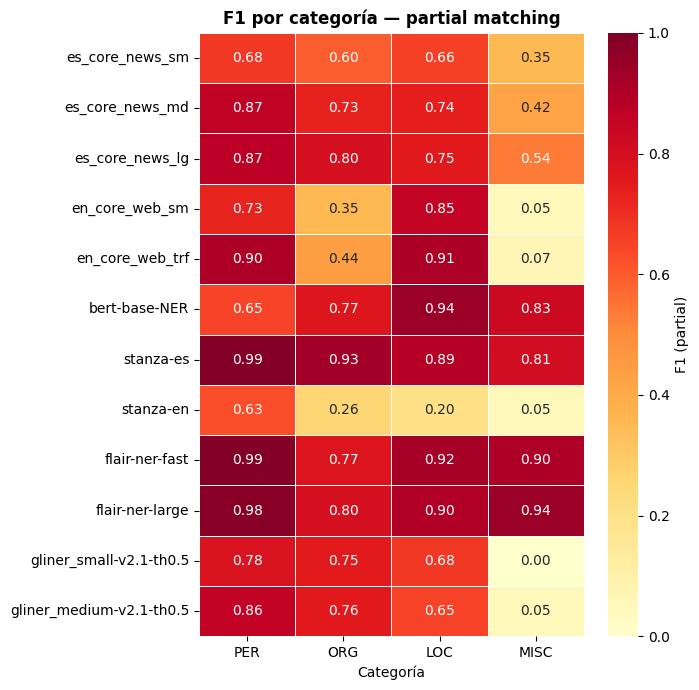

In [ ]:
CAT_RESULTS = []
all_fns = {**SPACY_PRED_FNS, **HF_PRED_FNS, **STANZA_PRED_FNS,
           **FLAIR_PRED_FNS, **GLINER_PRED_FNS}

for name, pred_fn in all_fns.items():
    lang   = 'EN' if any(k in name for k in ['web','bert-base','flair']) else 'ES'
    corpus = CORPUS_EN if lang=='EN' else CORPUS_ES
    try:
        cm = category_metrics(corpus, pred_fn)
        row = {'Modelo':name}
        for cat,m in cm.items():
            row[f'{cat}_F1']=m['F1']; row[f'{cat}_FP']=m['fp']
        CAT_RESULTS.append(row)
    except Exception as e:
        print(f'⚠️  {name}: {e}')

df_cat  = pd.DataFrame(CAT_RESULTS).set_index('Modelo')
f1_cols = [c for c in df_cat.columns if c.endswith('_F1')]
data_h  = df_cat[f1_cols].rename(columns=lambda c: c.replace('_F1',''))

fig, ax = plt.subplots(figsize=(7, max(4,len(df_cat)*0.5+1)))
sns.heatmap(data_h, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, vmin=0, vmax=1, ax=ax,
            cbar_kws={'label':'F1 (partial)'})
ax.set_title('F1 por categoría — partial matching', fontsize=12, fontweight='bold')
ax.set_xlabel('Categoría'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig('ner_heatmap_categories.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Pipeline de filtrado multicapa

- **Capa 1**: Reglas léxicas (stopwords, longitud mínima, mayúsculas, regex)
- **Capa 2**: Umbral de confianza (para modelos que exponen score)


In [ ]:
STOPWORDS_ES = {
    'el','la','los','las','un','una','unos','unas','de','del','al','en','con',
    'por','para','desde','que','se','no','si','como','más','pero','sus','su',
    'este','esta','estos','estas','ese','esa','aquel','cuando','donde','quien',
    'presidente','director','ministro','secretario','general',
    'español','española','europeo','europea','nacional','internacional',
}
_MONTHS_RE = re.compile(
    r'\b(enero|febrero|marzo|abril|mayo|junio|julio|agosto|'
    r'septiembre|octubre|noviembre|diciembre)\b', re.IGNORECASE
)
EXCL = [re.compile(r'^\d+$'), re.compile(r'^[a-záéíóúüñ]+$'),
        re.compile(r'^.{1}$'), _MONTHS_RE]

def rule_filter(entities):
    valid, rejected = [], []
    for ent in entities:
        s,e,label,span = ent; sl = span.lower().strip()
        if sl in STOPWORDS_ES:              rejected.append((ent,'stopword'));   continue
        if len(span.strip()) < 2:           rejected.append((ent,'too_short'));  continue
        if label in ('PER','ORG','LOC') and span and not span[0].isupper():
                                            rejected.append((ent,'no_upper'));   continue
        skip = any(p.search(sl) for p in EXCL)
        (rejected if skip else valid).append(ent if not skip else (ent,'regex'))
    # normalizar: valid es lista de tuplas 4-elem, rejected de (ent, motivo)
    valid = [x for x in valid if isinstance(x, tuple) and len(x)==4]
    return valid, rejected

def filter_pipeline(entities):
    valid, rej = rule_filter(entities)
    return {'final':valid, 'stats':{'original':len(entities),
                                    'filtered':len(valid),'rejected':len(rej)}}
print('✅ Pipeline de filtrado listo')


✅ Pipeline de filtrado listo


## 8. Comparativa antes/después de filtrado (capa 1: reglas)

In [ ]:
FILTER_RESULTS = []
all_fns_f = {**SPACY_PRED_FNS, **HF_PRED_FNS, **STANZA_PRED_FNS,
             **FLAIR_PRED_FNS, **GLINER_PRED_FNS}

print('── Evaluación con filtrado (capa 1: reglas) ──')
for name, pred_fn in all_fns_f.items():
    lang   = 'EN' if any(k in name for k in ['web','bert-base','flair']) else 'ES'
    corpus = CORPUS_EN if lang=='EN' else CORPUS_ES
    try:
        br, ar = [], []
        total_rej = 0
        for s in corpus:
            preds = pred_fn(s['text'])
            br.append(partial_metrics(s['entities'], preds))
            res = filter_pipeline(preds)
            ar.append(partial_metrics(s['entities'], res['final']))
            total_rej += res['stats']['rejected']
        ba = aggregate(br); aa = aggregate(ar)
        fp_red = (ba['fp']-aa['fp'])/ba['fp']*100 if ba['fp'] else 0
        FILTER_RESULTS.append({
            'Modelo':name,
            'Pre-P':ba['P'],'Pre-R':ba['R'],'Pre-F1':ba['F1'],
            'Post-P':aa['P'],'Post-R':aa['R'],'Post-F1':aa['F1'],
            'ΔF1':aa['F1']-ba['F1'],'ΔP':aa['P']-ba['P'],
            'FP antes':ba['fp'],'FP después':aa['fp'],
            '% FP red.':round(fp_red,1),'Rechazadas':total_rej,
        })
        print(f'  {name:35s}  F1 {ba["F1"]:.3f}→{aa["F1"]:.3f} '
              f'(Δ{aa["F1"]-ba["F1"]:+.3f})  P {ba["P"]:.3f}→{aa["P"]:.3f}  FP -{fp_red:.0f}%')
    except Exception as e:
        print(f'  ⚠️  {name}: {e}')

df_ba = pd.DataFrame(FILTER_RESULTS)
BA_SHOW = ['Modelo','Pre-P','Pre-R','Pre-F1','Post-P','Post-R','Post-F1','ΔF1','ΔP',
           'FP antes','FP después','% FP red.']
print()
try:
    from tabulate import tabulate
    print(tabulate(df_ba[BA_SHOW], headers='keys', tablefmt='fancy_grid',
                   showindex=False, floatfmt='.3f'))
except ImportError:
    print(df_ba[BA_SHOW].to_string(index=False))


── Evaluación con filtrado (capa 1: reglas) ──
  es_core_news_sm                      F1 0.610→0.363 (Δ-0.248)  P 0.602→0.624  FP -62%
  es_core_news_md                      F1 0.732→0.411 (Δ-0.321)  P 0.720→0.705  FP -58%
  es_core_news_lg                      F1 0.779→0.430 (Δ-0.349)  P 0.772→0.741  FP -54%
  en_core_web_sm                       F1 0.514→0.407 (Δ-0.106)  P 0.436→0.534  FP -64%
  en_core_web_trf                      F1 0.628→0.476 (Δ-0.151)  P 0.521→0.623  FP -68%
  bert-base-NER                        F1 0.755→0.374 (Δ-0.381)  P 0.635→0.941  FP -97%
  stanza-es                            F1 0.919→0.541 (Δ-0.377)  P 0.922→0.961  FP -81%
  stanza-en                            F1 0.276→0.155 (Δ-0.121)  P 0.343→0.251  FP -24%
  flair-ner-fast                       F1 0.931→0.610 (Δ-0.321)  P 0.931→0.973  FP -82%
  flair-ner-large                      F1 0.928→0.614 (Δ-0.314)  P 0.926→0.978  FP -87%
  gliner_small-v2.1-th0.5              F1 0.705→0.466 (Δ-0.239)  P 0.707→

## 9. Visualizaciones

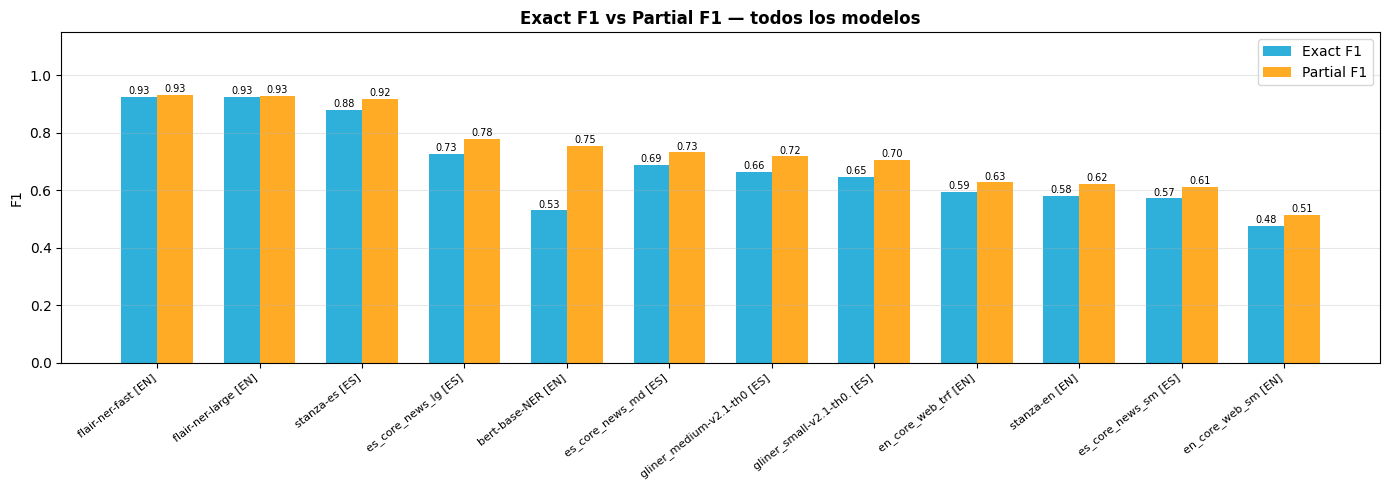

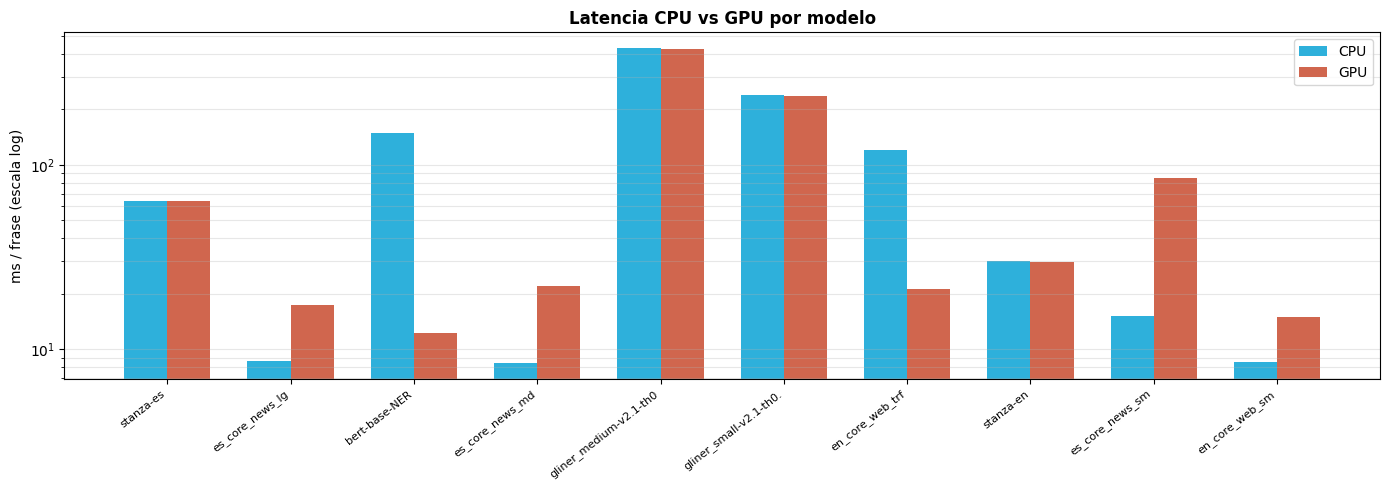

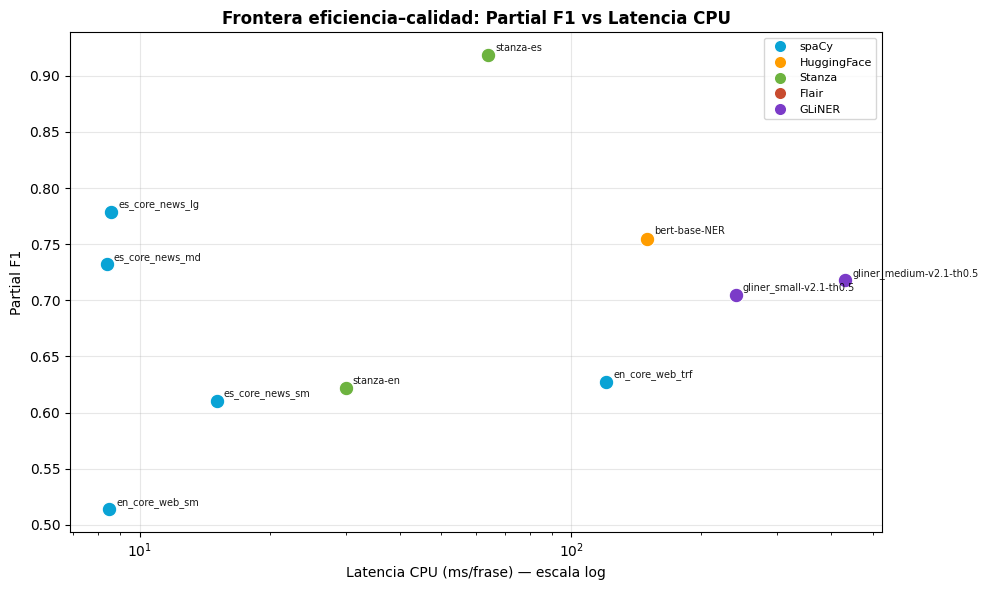

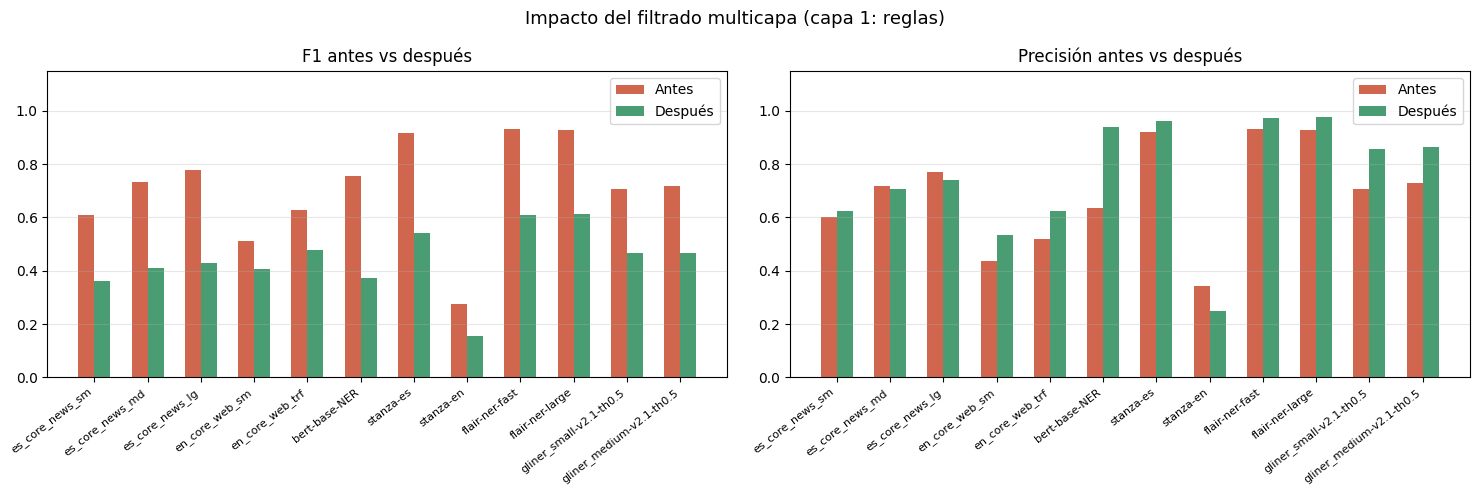

In [ ]:
# ── Gráfico 1: Exact vs Partial F1 ──────────────────────────
df_p = df_sorted.copy()
for c in ['Exact-F1','Partial-F1']: df_p[c] = pd.to_numeric(df_p[c], errors='coerce')
df_p = df_p.dropna(subset=['Exact-F1','Partial-F1'])
if not df_p.empty:
    labels = [f"{r['Modelo'][:22]} [{r['Idioma']}]" for _,r in df_p.iterrows()]
    x=np.arange(len(labels)); w=0.35
    fig,ax=plt.subplots(figsize=(14,5))
    b1=ax.bar(x-w/2,df_p['Exact-F1'],  w,label='Exact F1',  color='#09A3D5',alpha=0.85)
    b2=ax.bar(x+w/2,df_p['Partial-F1'],w,label='Partial F1',color='#FF9D00',alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels,rotation=38,ha='right',fontsize=8)
    ax.set_ylabel('F1'); ax.set_ylim(0,1.15)
    ax.set_title('Exact F1 vs Partial F1 — todos los modelos',fontweight='bold')
    ax.legend(); ax.grid(axis='y',alpha=0.3)
    for bar in [*b1,*b2]:
        h=bar.get_height()
        if h>0.02: ax.text(bar.get_x()+bar.get_width()/2,h+0.01,f'{h:.2f}',ha='center',fontsize=7)
    plt.tight_layout(); plt.savefig('ner_exact_vs_partial.png',dpi=150,bbox_inches='tight'); plt.show()

# ── Gráfico 2: CPU vs GPU timing ─────────────────────────────
df_t = df_sorted.copy()
df_t['CPU_ms'] = pd.to_numeric(df_t['CPU_ms'], errors='coerce')
df_t['GPU_ms'] = pd.to_numeric(df_t['GPU_ms'], errors='coerce')
df_t = df_t.dropna(subset=['CPU_ms'])
if not df_t.empty:
    has_gpu_data = df_t['GPU_ms'].notna().any()
    labels_t = [f"{r['Modelo'][:22]}" for _,r in df_t.iterrows()]
    x=np.arange(len(labels_t))
    w = 0.35 if has_gpu_data else 0.6
    fig,ax=plt.subplots(figsize=(14,5))
    offset = w/2 if has_gpu_data else 0
    ax.bar(x-offset, df_t['CPU_ms'], w, label='CPU', color='#09A3D5', alpha=0.85)
    if has_gpu_data:
        ax.bar(x+w/2, df_t['GPU_ms'].fillna(0), w, label='GPU', color='#C84B2F', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels_t,rotation=38,ha='right',fontsize=8)
    ax.set_ylabel('ms / frase (escala log)'); ax.set_yscale('log')
    title = 'Latencia CPU vs GPU por modelo' if has_gpu_data else 'Latencia CPU por modelo (no se detectó GPU)'
    ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(axis='y',alpha=0.3,which='both')
    plt.tight_layout(); plt.savefig('ner_timing.png',dpi=150,bbox_inches='tight'); plt.show()

# ── Gráfico 3: F1 vs latencia CPU (frontera eficiencia) ──────
if not df_t.empty:
    fig,ax=plt.subplots(figsize=(10,6))
    for _,r in df_t.iterrows():
        c=COLORS.get(r['Librería'],'#aaa')
        f1=float(r['Partial-F1']); cpu=float(r['CPU_ms'])
        ax.scatter(cpu,f1,color=c,s=110,zorder=3,edgecolor='white',linewidth=0.8)
        ax.annotate(r['Modelo'],xy=(cpu,f1),xytext=(5,3),
                    textcoords='offset points',fontsize=7,alpha=0.9)
    ax.set_xlabel('Latencia CPU (ms/frase) — escala log'); ax.set_xscale('log')
    ax.set_ylabel('Partial F1')
    ax.set_title('Frontera eficiencia–calidad: Partial F1 vs Latencia CPU',fontweight='bold')
    ax.grid(True,alpha=0.3)
    legend_p=[plt.Line2D([0],[0],marker='o',color='w',markerfacecolor=c,markersize=9,label=fw)
              for fw,c in COLORS.items()]
    ax.legend(handles=legend_p,fontsize=8)
    plt.tight_layout(); plt.savefig('ner_efficiency.png',dpi=150,bbox_inches='tight'); plt.show()

# ── Gráfico 4: Antes/después de filtrado ─────────────────────
if not df_ba.empty:
    x2=np.arange(len(df_ba)); w2=0.3
    fig,axes=plt.subplots(1,2,figsize=(15,5))
    for ax_,pre,post,ttl in [(axes[0],'Pre-F1','Post-F1','F1'),(axes[1],'Pre-P','Post-P','Precisión')]:
        ax_.bar(x2-w2/2,df_ba[pre], w2,label='Antes', color='#C84B2F',alpha=0.85)
        ax_.bar(x2+w2/2,df_ba[post],w2,label='Después',color='#2a8c5a',alpha=0.85)
        ax_.set_xticks(x2); ax_.set_xticklabels(df_ba['Modelo'],rotation=38,ha='right',fontsize=8)
        ax_.set_title(f'{ttl} antes vs después'); ax_.set_ylim(0,1.15)
        ax_.legend(); ax_.grid(axis='y',alpha=0.3)
    plt.suptitle('Impacto del filtrado multicapa (capa 1: reglas)',fontsize=13)
    plt.tight_layout(); plt.savefig('filter_before_after.png',dpi=150,bbox_inches='tight'); plt.show()


## 10. 💾 Exportación a CSV y LaTeX

In [ ]:
df_sorted.to_csv('ner_results.csv', index=True, float_format='%.3f')
df_ba.to_csv('ner_filter_comparison.csv', index=False, float_format='%.3f')
print('✅ CSVs guardados')

latex_cols = ['Librería','Modelo','Idioma','Exact-F1','Partial-F1','Partial-P','Partial-R','CPU_ms','GPU_ms']
df_l = df_sorted.reindex(columns=latex_cols).copy()
df_l.columns = ['Librería','Modelo','Idioma',
                r'$F_1^{\text{ex}}$',r'$F_1^{\text{par}}$',
                'P','R','CPU (ms)','GPU (ms)']
with open('tab_ner_models.tex','w') as f:
    f.write(df_l.to_latex(index=False, float_format='%.3f',
        column_format='llcrrrrr',
        caption='Comparativa modelos NER — CoNLL-2002 ES / Gold EN.',
        label='tab:ner_comparison', escape=False))

ba_cols = ['Modelo','Pre-P','Pre-F1','Post-P','Post-F1','ΔF1','% FP red.']
df_ba_l = df_ba.reindex(columns=ba_cols).copy()
df_ba_l.columns = ['Modelo','Pre-P',r'Pre-$F_1$','Post-P',r'Post-$F_1$',
                   r'$\Delta F_1$',r'\% FP elim.']
with open('tab_filter_comparison.tex','w') as f:
    f.write(df_ba_l.to_latex(index=False, float_format='%.3f',
        column_format='lrrrrrr',
        caption='Impacto del filtrado multicapa — CoNLL-2002 ES.',
        label='tab:filter_comparison', escape=False))

print('✅ LaTeX: tab_ner_models.tex, tab_filter_comparison.tex')


✅ CSVs guardados
✅ LaTeX: tab_ner_models.tex, tab_filter_comparison.tex


---
## Conclusiones

1. **Gap Exact vs Partial**: mide errores de tokenización, no de semántica. Un gap alto indica que el modelo detecta la entidad correctamente pero se equivoca en los bordes del span.

2. **F1 por categoría**: LOC y MISC suelen generar más FP que PER/ORG. El heatmap identifica dónde actuar con el filtrado.

3. **Filtrado por reglas**: elimina un porcentaje significativo de FP al coste de una pequeña caída en Recall, sin coste computacional adicional.

4. **CPU vs GPU**: los modelos transformer (spaCy trf, BERT, Flair, GLiNER) obtienen mayor aceleración en GPU; los modelos CNN de spaCy apenas se benefician.

### Próximos pasos
- Ampliar muestra a 500–1000 frases para métricas más estables
- Evaluar con dominio propio (legal/clínico)
- Integrar en FastAPI: endpoint que recibe texto y devuelve entidades filtradas
